In [8]:
import random
from math import sqrt, pi, exp
from random import choices

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import scipy.stats as st
from statsmodels.distributions.empirical_distribution import ECDF

In [9]:
n = 25
y = st.expon(scale=1).rvs(size=n)

Пункт А)

In [10]:
def mod(v: list, grid_size: int = 512):
    v = np.asarray(v, dtype=float)
    if v.size == 0:
        raise ValueError("Пустая выборка")
    if v.size == 1:
        return float(v[0])

    kde = gaussian_kde(v)
    left, right = float(v.min()), float(v.max())
    if left == right:
        return left

    xs = np.linspace(left, right, grid_size)
    dens = kde(xs)
    return float(xs[int(np.argmax(dens))])

def med(v: list):
    v = sorted(v)
    n = len(v)
    if n == 0:
        raise ValueError("Пустая выборка")
    mid = n // 2
    if n % 2 == 1:
        return v[mid]
    return (v[mid - 1] + v[mid]) / 2

def l(v: list):
    return max(v) - min(v)

def mat_exp_d(v: list):
    m_e = sum(v) / len(v)
    return m_e

def cntr_m(v : list, p: int):
    m = 0
    mat_exp = mat_exp_d(v)
    for i in range(len(v)):
        m += (v[i] - mat_exp) ** p
    m /= len(v)
    return m

def assim_k(v: list):
    return cntr_m(v, 3) / cntr_m(v, 2)**(3/2)


print("Мода: ", mod(y))
print("Медиана: ", med(y))
print("Размах: ", l(y))
print("Коэффициент асимметрии: ", assim_k(y))


Мода:  0.2843553998849547
Медиана:  0.4592484730542257
Размах:  1.4675045826012327
Коэффициент асимметрии:  0.6431654604786805


Пункт Б)

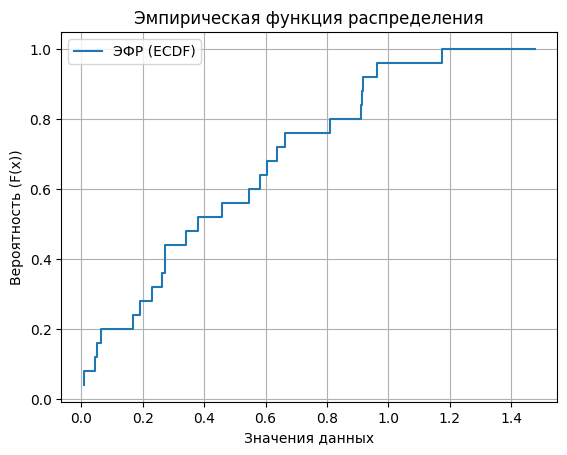

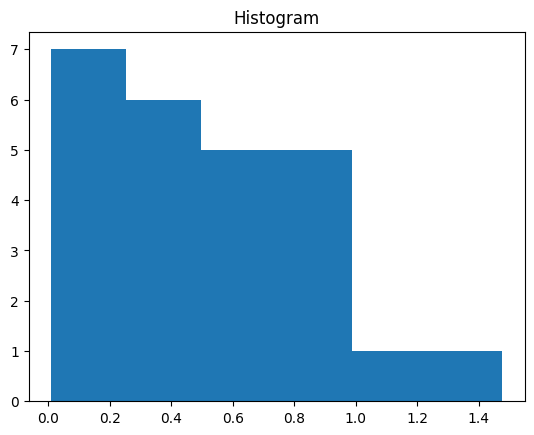

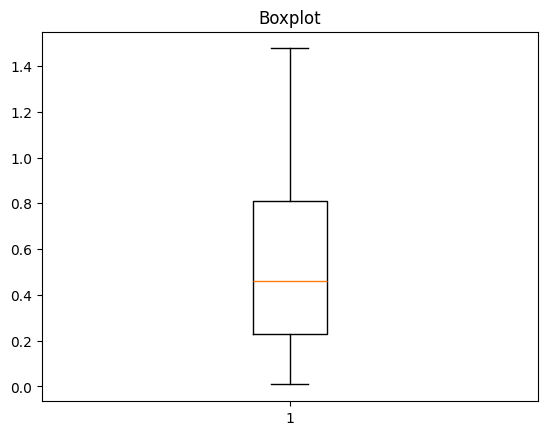

In [11]:
def ecdfunc(v: list):
    ecdf = ECDF(v)
    plt.step(ecdf.x, ecdf.y, label='ЭФР (ECDF)')
    plt.ylabel('Вероятность (F(x))')
    plt.xlabel('Значения данных')
    plt.title('Эмпирическая функция распределения')
    plt.grid(True)
    plt.legend()
    plt.show()

def histogram(v: list):
    plt.hist(v, bins="auto")
    plt.title("Histogram")
    plt.show()

def bxp(v: list):
    plt.boxplot(v)
    plt.title("Boxplot")
    plt.show()

ecdfunc(y)
histogram(y)
bxp(y)

Пункт С)

In [ ]:
def normal_pdf(x, mu, sigma):
    # плотность N(mu, sigma^2)
    return (1.0 / (sigma * sqrt(2*pi))) * np.exp(-0.5 * ((x - mu)/sigma) ** 2)

def compare_density_mean_clt_vs_bootstrap(y, B=5000, grid_size=400, show=True):

    y = np.array(y, dtype=float)
    n = len(y)

    # 1) Простейшая ЦПТ : для Exp(1) теоретически E[X]=1, Var(X)=1
    #    => X̄ ≈ N(1, 1/n). Параметры распределения НЕ оцениваем по выборке.
    xbar = y.mean()                   
    s = y.std(ddof=1)                 
    mu_clt = 1.0
    sigma_xbar = 1.0 / sqrt(n)

    # 2) Bootstrap распределение среднего
    #    Делаем B выборок с возвращением и считаем их среднее
    boot_means = np.empty(B)
    for b in range(B):
        sample = choices(y, k=n)      # bootstrap sample
        boot_means[b] = sum(sample) / n

    # 3) KDE по bootstrap
    kde = gaussian_kde(boot_means)

    # 4) Общая сетка для сравнения плотностей
    left = min(boot_means.min(), mu_clt - 4 * sigma_xbar)
    right = max(boot_means.max(), mu_clt + 4 * sigma_xbar)
    xs = np.linspace(left, right, grid_size)

    clt_pdf = normal_pdf(xs, mu_clt, sigma_xbar)
    boot_pdf = kde(xs)

    if show:
        plt.figure()
        plt.plot(xs, clt_pdf, label="ЦПТ: N(1, 1/√n)")
        plt.plot(xs, boot_pdf, label="Bootstrap KDE")
        plt.title("Плотность распределения среднего: ЦПТ vs Bootstrap")
        plt.xlabel("t")
        plt.ylabel("f(t)")
        plt.grid(True)
        plt.legend()
        plt.show()

   

Пункт Д)

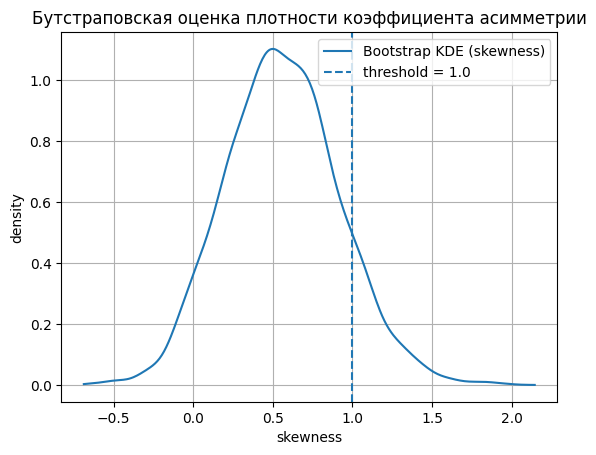


Пункт (d):
P(skewness < 1) = 0.8886


In [13]:
def bootstrap_skewness_density_and_prob(y, B=5000, grid_size=400, threshold=1.0, show=True):
    """
    Строит бутстраповскую оценку плотности коэффициента асимметрии (skewness)
    и оценивает вероятность P(skewness < threshold).
    """
    y = np.array(y, dtype=float)
    n = len(y)

    boot_skews = np.empty(B)
    for b in range(B):
        sample = choices(y, k=n)
        boot_skews[b] = assim_k(sample)

    # KDE плотности асимметрии
    kde = gaussian_kde(boot_skews)

    left = boot_skews.min()
    right = boot_skews.max()
    xs = np.linspace(left, right, grid_size)
    dens = kde(xs)

    # Вероятность по бутстрапу:
    prob = np.mean(boot_skews < threshold)

    if show:
        plt.figure()
        plt.plot(xs, dens, label="Bootstrap KDE (skewness)")
        plt.axvline(threshold, linestyle="--", label=f"threshold = {threshold}")
        plt.title("Бутстраповская оценка плотности коэффициента асимметрии")
        plt.xlabel("skewness")
        plt.ylabel("density")
        plt.grid(True)
        plt.legend()
        plt.show()

    return {
        "boot_skews": boot_skews,
        "xs": xs,
        "density": dens,
        "P_skew_less_than_threshold": prob
    }

res_d = bootstrap_skewness_density_and_prob(y, B=5000, threshold=1.0, show=True)
print("\nПункт (d):")
print("P(skewness < 1) =", res_d["P_skew_less_than_threshold"])

Пункт Е)

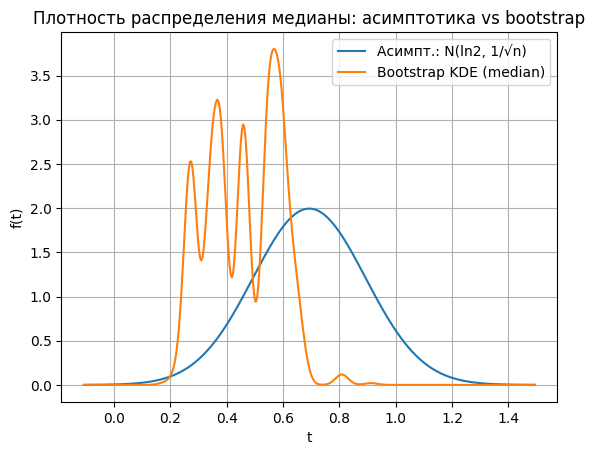

In [14]:
def compare_density_median_clt_vs_bootstrap(y, B=5000, grid_size=400, show=True):
    """Сравнение плотности распределения медианы выборки.

    Для Exp(1):
      - теоретическая медиана m = ln 2
      - f(m) = e^{-m} = 1/2
      - асимптотически: Med ≈ N(m, 1/(4 n f(m)^2)) = N(ln2, 1/n)

    Строим:
      1) Асимптотическую нормальную плотность
      2) Бутстраповскую KDE по распределению медианы
    """
    y = np.array(y, dtype=float)
    n = len(y)

    # 1) Теоретические параметры для Exp(1)
    mu_clt = float(np.log(2.0))
    sigma_med = 1.0 / sqrt(n)  # т.к. Var(median) ≈ 1/n

    # Медиана по исходной выборке (для отчёта)
    med_hat = float(np.median(y))

    # 2) Bootstrap распределение медианы
    boot_meds = np.empty(B)
    for b in range(B):
        sample = choices(y, k=n)
        boot_meds[b] = float(np.median(sample))

    # 3) KDE по bootstrap
    kde = gaussian_kde(boot_meds)

    # 4) Общая сетка
    left = min(boot_meds.min(), mu_clt - 4 * sigma_med)
    right = max(boot_meds.max(), mu_clt + 4 * sigma_med)
    xs = np.linspace(left, right, grid_size)

    clt_pdf = normal_pdf(xs, mu_clt, sigma_med)
    boot_pdf = kde(xs)

    if show:
        plt.figure()
        plt.plot(xs, clt_pdf, label="Асимпт.: N(ln2, 1/√n)")
        plt.plot(xs, boot_pdf, label="Bootstrap KDE (median)")
        plt.title("Плотность распределения медианы: асимптотика vs bootstrap")
        plt.xlabel("t")
        plt.ylabel("f(t)")
        plt.grid(True)
        plt.legend()
        plt.show()

    dx = xs[1] - xs[0]



res_e = compare_density_median_clt_vs_bootstrap(y, B=5000, show=True)